# Reinforcement Learning: Value Functions and Bellman Optimality
## A visual, mathematical, beginner-friendly notebook

This notebook follows the lecture step by step and turns the concepts into:
- intuitive explanations,
- mathematical derivations,
- diagrams,
- numerical examples,
- interactive-style experiments,
- and a complete recycling-robot solution.

## Learning roadmap

1. What does **value** mean?
2. State-value function $V_\pi(s)$
3. Action-value function $Q_\pi(s,a)$
4. Bellman expectation equation
5. Backup diagrams
6. Policy comparison and optimal policies
7. Optimal value functions $V_*(s)$ and $Q_*(s,a)$
8. Bellman optimality equation
9. Value iteration
10. Recycling robot example


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

print("Imports loaded successfully.")


Imports loaded successfully.


# 1. What does “Value” mean?

In reinforcement learning, **value is not the immediate reward**.

Instead, value describes the **expected cumulative reward in the future**.

A useful intuition is a player participating in a tournament. A player may perform poorly in the first two matches but still be valuable if their expected total contribution over the entire tournament is high.

Therefore:

> **Immediate reward asks:** What did I get now?  
> **Value asks:** How much reward do I expect from here onward?


# 2. Return: the quantity behind value

The discounted return from time $t$ is

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots
$$

or equivalently,

$$
G_t = \sum_{k=0}^{\infty}\gamma^k R_{t+k+1}
$$

where:

- $R_{t+k+1}$ is a future reward,
- $\gamma$ is the discount factor,
- $0 \leq \gamma < 1$.

The discount factor gives less weight to rewards that arrive farther in the future.


Reward sequence: [2 1 4 0 5]
gamma =  0.2  -->  return = 2.3680
gamma =  0.5  -->  return = 3.8125
gamma =  0.9  -->  return = 9.4205
gamma = 0.99  -->  return = 11.7134


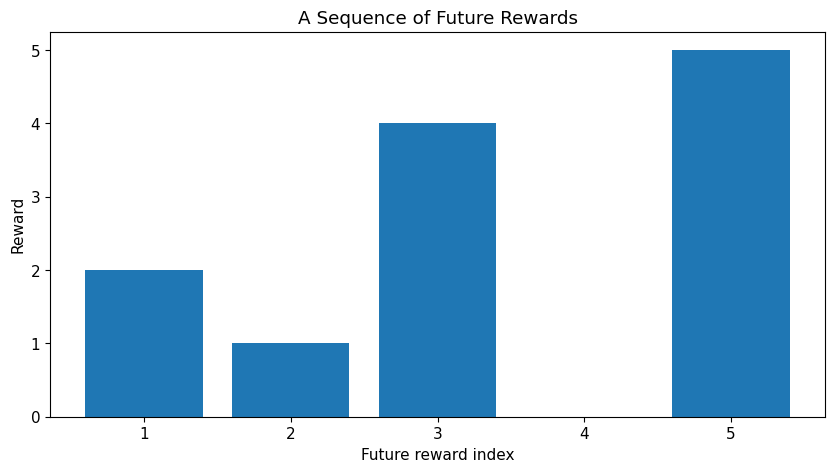

In [2]:
rewards = np.array([2, 1, 4, 0, 5])
gammas = [0.2, 0.5, 0.9, 0.99]

def discounted_return(rewards, gamma):
    return sum((gamma ** k) * r for k, r in enumerate(rewards))

print("Reward sequence:", rewards)

for gamma in gammas:
    print(f"gamma = {gamma:>4}  -->  return = {discounted_return(rewards, gamma):.4f}")

plt.bar(range(1, len(rewards) + 1), rewards)
plt.xlabel("Future reward index")
plt.ylabel("Reward")
plt.title("A Sequence of Future Rewards")
plt.show()


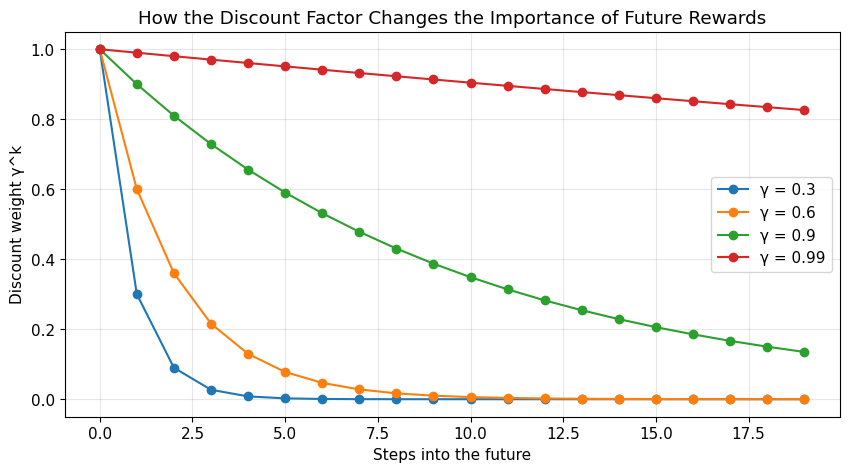

In [3]:
steps = np.arange(0, 20)

for gamma in [0.3, 0.6, 0.9, 0.99]:
    plt.plot(steps, gamma ** steps, marker="o", label=f"γ = {gamma}")

plt.xlabel("Steps into the future")
plt.ylabel("Discount weight γ^k")
plt.title("How the Discount Factor Changes the Importance of Future Rewards")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 3. State-value function

The **state-value function** answers:

> If the agent is currently in state $s$ and follows policy $\pi$, what long-term return should we expect?

It is written as:

$$
V_\pi(s)
=
\mathbb{E}_\pi[G_t \mid S_t=s]
$$

Substituting the discounted return:

$$
V_\pi(s)
=
\mathbb{E}_\pi
\left[
\sum_{k=0}^{\infty}
\gamma^k R_{t+k+1}
\mid
S_t=s
\right]
$$

### Key idea

$V_\pi(s)$ depends on:

1. The current state $s$.
2. The future trajectory.
3. The policy $\pi$ used by the agent.
4. The rewards received along that trajectory.


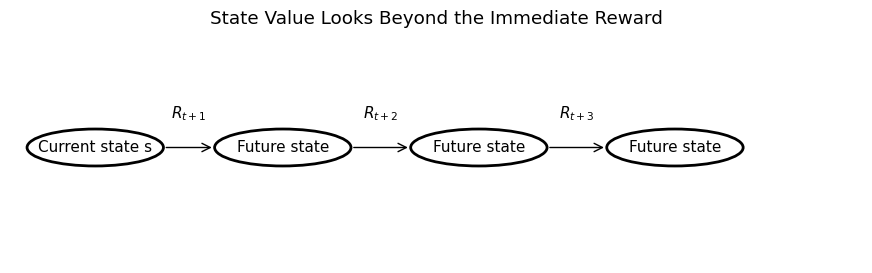

In [5]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.axis("off")

points = [(0.1, 0.5), (0.32, 0.5), (0.55, 0.5), (0.78, 0.5)]
labels = ["Current state s", "Future state", "Future state", "Future state"]

for point, label in zip(points, labels):
    ax.add_patch(Circle(point, 0.08, fill=False, linewidth=2))
    ax.text(*point, label, ha="center", va="center")

for i in range(len(points) - 1):
    ax.add_patch(FancyArrowPatch(
        (points[i][0] + 0.08, points[i][1]),
        (points[i+1][0] - 0.08, points[i+1][1]),
        arrowstyle="->",
        mutation_scale=15
    ))

ax.text(0.21, 0.63, r"$R_{t+1}$", ha="center")
ax.text(0.435, 0.63, r"$R_{t+2}$", ha="center")
ax.text(0.665, 0.63, r"$R_{t+3}$", ha="center")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.title("State Value Looks Beyond the Immediate Reward")
plt.show()

# 4. Action-value function

The **action-value function** is slightly more specific.

It answers:

> If the agent is in state $s$, takes action $a$, and then follows policy $\pi$, what return should we expect?

The notation is:

$$
Q_\pi(s,a)
=
\mathbb{E}_\pi[
G_t
\mid
S_t=s,
A_t=a
]
$$

The difference is:

- $V_\pi(s)$ asks about a **state**.
- $Q_\pi(s,a)$ asks about a **state-action pair**.

This distinction becomes extremely important when choosing which action is best.


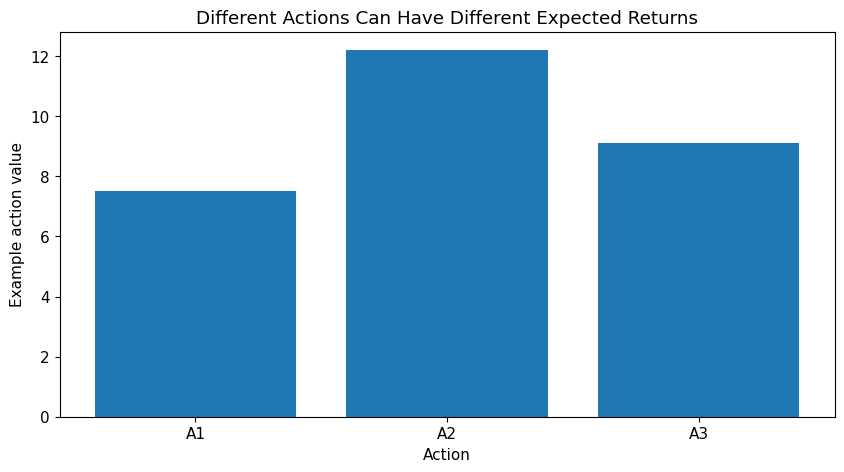

Best action in this illustrative example: A2


In [6]:
actions = ["A1", "A2", "A3"]
example_q_values = [7.5, 12.2, 9.1]

plt.bar(actions, example_q_values)
plt.xlabel("Action")
plt.ylabel("Example action value")
plt.title("Different Actions Can Have Different Expected Returns")
plt.show()

best_action = actions[np.argmax(example_q_values)]
print("Best action in this illustrative example:", best_action)


# 5. The core relationship between state value and action value

Imagine the agent is in state $s$.

The policy $\pi(a|s)$ specifies how likely the agent is to choose each action.

Therefore the state value can be interpreted as a policy-weighted combination of action values:

$$
V_\pi(s)
=
\sum_a \pi(a|s)Q_\pi(s,a)
$$

This equation gives a useful intuition:

> State value describes the expected long-term value before selecting the action.  
> Action value describes the expected long-term value after committing to a particular action.


In [7]:
actions = ["A1", "A2", "A3"]
policy_probs = np.array([0.2, 0.5, 0.3])
q_values = np.array([7.0, 12.0, 9.0])

v_state = np.sum(policy_probs * q_values)

print("Actions:       ", actions)
print("Policy π(a|s): ", policy_probs)
print("Qπ(s,a):       ", q_values)
print()
print("Vπ(s) = Σ π(a|s) Qπ(s,a)")
print("Vπ(s) =", v_state)


Actions:        ['A1', 'A2', 'A3']
Policy π(a|s):  [0.2 0.5 0.3]
Qπ(s,a):        [ 7. 12.  9.]

Vπ(s) = Σ π(a|s) Qπ(s,a)
Vπ(s) = 10.1


# 6. Bellman expectation equation

The Bellman equation provides the central recursive insight of this lecture:

> The value of the current state can be expressed using the reward received now plus the discounted value of possible next states.

For a policy $\pi$:

$$
V_\pi(s)
=
\sum_a
\pi(a|s)
\sum_{s',r}
p(s',r|s,a)
\left[
r+\gamma V_\pi(s')
\right]
$$

Let's interpret every term.

### $\pi(a|s)$
Probability that the policy chooses action $a$.

### $p(s',r|s,a)$
Probability of transitioning to next state $s'$ and receiving reward $r$.

### $r$
Immediate reward collected during the transition.

### $\gamma V_\pi(s')$
Discounted long-term value after reaching the next state.

The Bellman equation therefore averages over:

1. possible actions,
2. possible next states,
3. possible rewards.


# 7. Backup diagram

A **backup diagram** visually represents the one-step reasoning used by the Bellman equation.

Starting from one state:

1. The agent can choose multiple actions.
2. Each action can lead to multiple possible next states.
3. Each transition can produce a reward.
4. The current value is built from those possible outcomes.


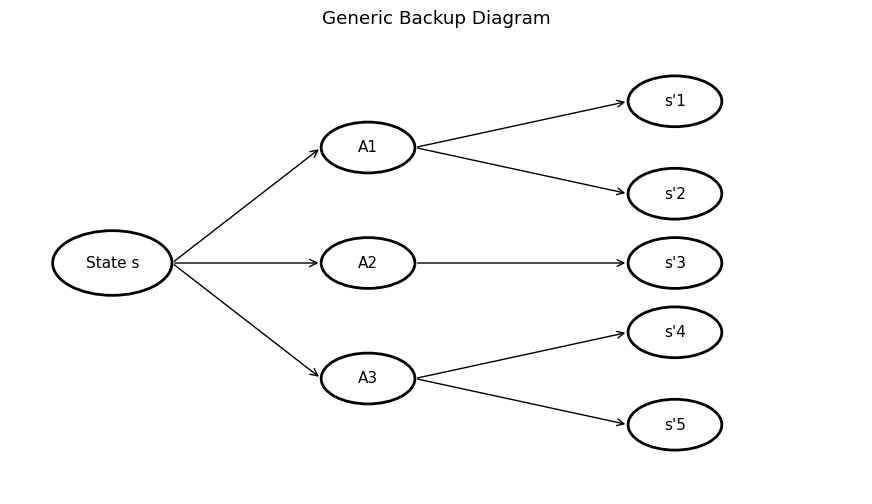

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.axis("off")

s = (0.12, 0.5)
actions_pos = [(0.42, 0.75), (0.42, 0.5), (0.42, 0.25)]
next_states = [(0.78, 0.85), (0.78, 0.65), (0.78, 0.5), (0.78, 0.35), (0.78, 0.15)]

ax.add_patch(Circle(s, 0.07, fill=False, linewidth=2))
ax.text(*s, "State s", ha="center", va="center")

for i, p in enumerate(actions_pos, 1):
    ax.add_patch(Circle(p, 0.055, fill=False, linewidth=2))
    ax.text(*p, f"A{i}", ha="center", va="center")
    ax.add_patch(FancyArrowPatch(
        (s[0] + 0.07, s[1]),
        (p[0] - 0.055, p[1]),
        arrowstyle="->",
        mutation_scale=13
    ))

for i, p in enumerate(next_states, 1):
    ax.add_patch(Circle(p, 0.055, fill=False, linewidth=2))
    ax.text(*p, f"s'{i}", ha="center", va="center")

connections = [
    (actions_pos[0], next_states[0]),
    (actions_pos[0], next_states[1]),
    (actions_pos[1], next_states[2]),
    (actions_pos[2], next_states[3]),
    (actions_pos[2], next_states[4]),
]

for a, ns in connections:
    ax.add_patch(FancyArrowPatch(
        (a[0] + 0.055, a[1]),
        (ns[0] - 0.055, ns[1]),
        arrowstyle="->",
        mutation_scale=12
    ))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.title("Generic Backup Diagram")
plt.show()


# 8. Policy comparison

Suppose we have two policies $\pi$ and $\pi'$.

The lecture defines $\pi$ as better than $\pi'$ when:

$$
V_\pi(s)
\geq
V_{\pi'}(s)
\quad
\text{for all states } s
$$

This is called **policy dominance**.

A policy is not globally better merely because it performs well in some states. To dominate another policy under this definition, it must provide at least as much expected return in every state.


# 9. Optimal value functions

The optimal state-value function is:

$$
V_*(s)
=
\max_\pi V_\pi(s)
$$

The optimal action-value function is:

$$
Q_*(s,a)
=
\max_\pi Q_\pi(s,a)
$$

An optimal policy chooses actions that maximize long-term expected return.

A central relationship is:

$$
V_*(s)
=
\max_a Q_*(s,a)
$$

This means:

> To find the best value of a state, compare all possible actions and choose the one with the highest optimal action value.


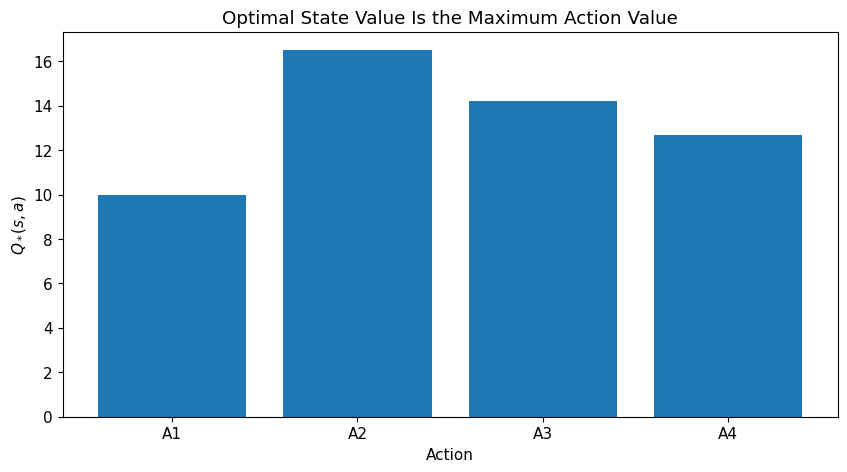

Q* values: [10.  16.5 14.2 12.7]
Optimal action: A2
V*(s) = 16.5


In [9]:
actions = ["A1", "A2", "A3", "A4"]
q_star = np.array([10.0, 16.5, 14.2, 12.7])

best_index = np.argmax(q_star)

plt.bar(actions, q_star)
plt.xlabel("Action")
plt.ylabel(r"$Q_*(s,a)$")
plt.title("Optimal State Value Is the Maximum Action Value")
plt.show()

print("Q* values:", q_star)
print("Optimal action:", actions[best_index])
print("V*(s) =", q_star[best_index])


# 10. Bellman optimality equation

The Bellman expectation equation averages over actions according to a policy.

The **Bellman optimality equation** instead chooses the best action:

$$
V_*(s)
=
\max_a
\sum_{s',r}
p(s',r|s,a)
\left[
r+\gamma V_*(s')
\right]
$$

The key difference is:

### Bellman expectation equation
Uses:

$$
\sum_a \pi(a|s)
$$

### Bellman optimality equation
Uses:

$$
\max_a
$$

So instead of evaluating a given policy, the optimality equation searches for the best possible decision.


# 11. Value iteration

The lecture's practical solution method repeatedly updates state values.

A Bellman optimality update is:

$$
V_{k+1}(s)
=
\max_a
\sum_{s',r}
p(s',r|s,a)
\left[
r+\gamma V_k(s')
\right]
$$

The process is:

1. Start with an initial guess for every state value.
2. Compute a new value using the Bellman optimality equation.
3. Repeat.
4. Continue until the values stop changing significantly.

This process is called **value iteration**.


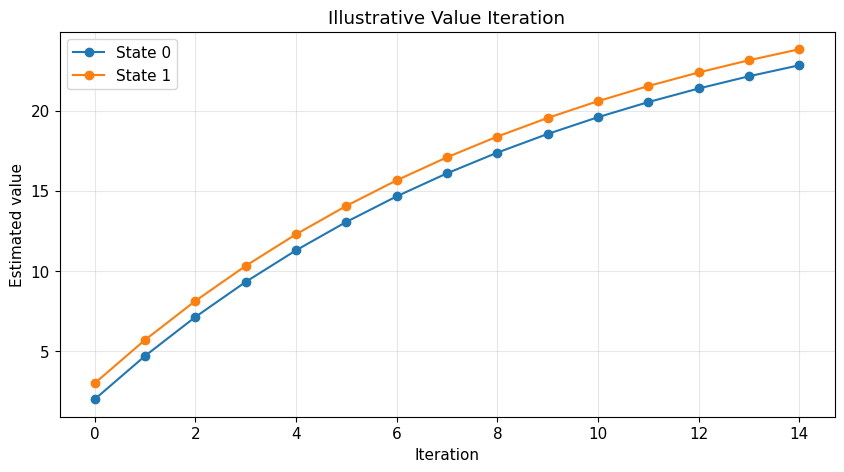

In [10]:
# A tiny illustrative value-iteration process.
# This is not yet the recycling robot.

gamma = 0.9
V = np.array([0.0, 0.0])

history = []

for iteration in range(15):
    new_V0 = max(
        1 + gamma * V[0],
        2 + gamma * V[1]
    )

    new_V1 = max(
        0 + gamma * V[0],
        3 + gamma * V[1]
    )

    V = np.array([new_V0, new_V1])
    history.append(V.copy())

history = np.array(history)

plt.plot(history[:, 0], marker="o", label="State 0")
plt.plot(history[:, 1], marker="o", label="State 1")
plt.xlabel("Iteration")
plt.ylabel("Estimated value")
plt.title("Illustrative Value Iteration")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 12. Recycling robot MDP

The lecture's main practical example is a recycling robot.

The robot has two battery states:

$$
\mathcal{S}=\{High, Low\}
$$

Possible actions:

### High battery
- Search
- Wait

### Low battery
- Search
- Wait
- Recharge

The model includes:

- $\alpha$: probability of staying High after searching from High.
- $\beta$: probability of staying Low after searching from Low.
- $r_{search}$: reward for searching.
- $r_{wait}$: reward for waiting.
- $r_{rescue}$: reward when the battery dies and recovery is needed.

The lecture uses the Bellman optimality equation to calculate the optimal values.


In [11]:
# Parameters for the recycling robot.
# You can change these and rerun the notebook.

alpha = 0.7
beta = 0.6

r_search = 3.0
r_wait = 1.0
r_rescue = -3.0

gamma = 0.9

print("alpha =", alpha)
print("beta =", beta)
print("r_search =", r_search)
print("r_wait =", r_wait)
print("r_rescue =", r_rescue)
print("gamma =", gamma)


alpha = 0.7
beta = 0.6
r_search = 3.0
r_wait = 1.0
r_rescue = -3.0
gamma = 0.9


## Bellman optimality update for High

For a High battery state:

### Search

$$
Q(High,Search)
=
\alpha
\left[
r_{search}+\gamma V(High)
\right]
+
(1-\alpha)
\left[
r_{search}+\gamma V(Low)
\right]
$$

### Wait

$$
Q(High,Wait)
=
r_{wait}
+
\gamma V(High)
$$

Therefore:

$$
V(High)
=
\max
\left(
Q(High,Search),
Q(High,Wait)
\right)
$$


## Bellman optimality update for Low

### Search

$$
Q(Low,Search)
=
\beta
\left[
r_{search}+\gamma V(Low)
\right]
+
(1-\beta)
\left[
r_{rescue}+\gamma V(High)
\right]
$$

### Wait

$$
Q(Low,Wait)
=
r_{wait}
+
\gamma V(Low)
$$

### Recharge

$$
Q(Low,Recharge)
=
\gamma V(High)
$$

Therefore:

$$
V(Low)
=
\max
\left(
Q(Low,Search),
Q(Low,Wait),
Q(Low,Recharge)
\right)
$$


In [12]:
def robot_action_values(V_high, V_low, alpha, beta,
                        r_search, r_wait, r_rescue, gamma):
    q_high_search = (
        alpha * (r_search + gamma * V_high)
        + (1 - alpha) * (r_search + gamma * V_low)
    )

    q_high_wait = (
        r_wait + gamma * V_high
    )

    q_low_search = (
        beta * (r_search + gamma * V_low)
        + (1 - beta) * (r_rescue + gamma * V_high)
    )

    q_low_wait = (
        r_wait + gamma * V_low
    )

    q_low_recharge = (
        gamma * V_high
    )

    return {
        "High": {
            "Search": q_high_search,
            "Wait": q_high_wait
        },
        "Low": {
            "Search": q_low_search,
            "Wait": q_low_wait,
            "Recharge": q_low_recharge
        }
    }


q = robot_action_values(
    0, 0,
    alpha, beta,
    r_search, r_wait,
    r_rescue, gamma
)

q


{'High': {'Search': 3.0, 'Wait': 1.0},
 'Low': {'Search': 0.5999999999999996, 'Wait': 1.0, 'Recharge': 0.0}}

# 13. Solve the recycling robot using value iteration

We repeatedly apply the Bellman optimality update until convergence.

Convergence means that the maximum change in value becomes smaller than a chosen tolerance.


In [13]:
def value_iteration_robot(
    alpha=0.7,
    beta=0.6,
    r_search=3.0,
    r_wait=1.0,
    r_rescue=-3.0,
    gamma=0.9,
    tolerance=1e-10,
    max_iterations=10000
):
    V_high = 0.0
    V_low = 0.0

    history = []

    for iteration in range(max_iterations):

        q = robot_action_values(
            V_high,
            V_low,
            alpha,
            beta,
            r_search,
            r_wait,
            r_rescue,
            gamma
        )

        new_V_high = max(q["High"].values())
        new_V_low = max(q["Low"].values())

        delta = max(
            abs(new_V_high - V_high),
            abs(new_V_low - V_low)
        )

        V_high = new_V_high
        V_low = new_V_low

        history.append(
            (iteration, V_high, V_low, delta)
        )

        if delta < tolerance:
            break

    q_final = robot_action_values(
        V_high,
        V_low,
        alpha,
        beta,
        r_search,
        r_wait,
        r_rescue,
        gamma
    )

    policy = {
        "High": max(q_final["High"], key=q_final["High"].get),
        "Low": max(q_final["Low"], key=q_final["Low"].get)
    }

    return V_high, V_low, q_final, policy, history


V_high, V_low, q_final, optimal_policy, history = value_iteration_robot(
    alpha=alpha,
    beta=beta,
    r_search=r_search,
    r_wait=r_wait,
    r_rescue=r_rescue,
    gamma=gamma
)

print("Optimal V(High):", V_high)
print("Optimal V(Low): ", V_low)
print()
print("Optimal policy:")
print(optimal_policy)


Optimal V(High): 23.6220472432519
Optimal V(Low):  21.259842518842447

Optimal policy:
{'High': 'Search', 'Low': 'Recharge'}


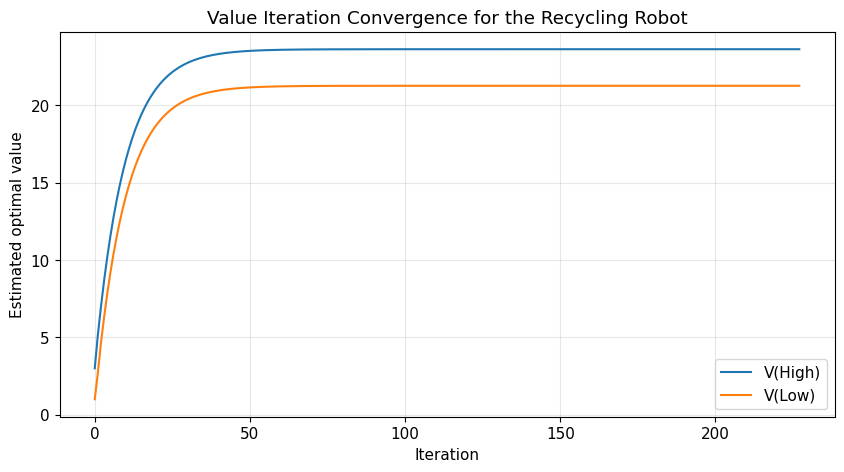

In [14]:
history_array = np.array(history)

plt.plot(
    history_array[:, 0],
    history_array[:, 1],
    label="V(High)"
)

plt.plot(
    history_array[:, 0],
    history_array[:, 2],
    label="V(Low)"
)

plt.xlabel("Iteration")
plt.ylabel("Estimated optimal value")
plt.title("Value Iteration Convergence for the Recycling Robot")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [15]:
print("Final action values")
print("=" * 45)

for state, action_values in q_final.items():
    print(f"\nState: {state}")
    for action, value in action_values.items():
        marker = " <-- chosen" if optimal_policy[state] == action else ""
        print(f"  {action:10s}: {value:10.4f}{marker}")


Final action values

State: High
  Search    :    23.6220 <-- chosen
  Wait      :    22.2598

State: Low
  Search    :    20.5843
  Wait      :    20.1339
  Recharge  :    21.2598 <-- chosen


# 14. Visualizing the optimal policy

The value function tells us **how good** each state is.

The policy tells us **what to do** in each state.

Together they answer the reinforcement-learning objective:

> Find actions that maximize long-term expected return.


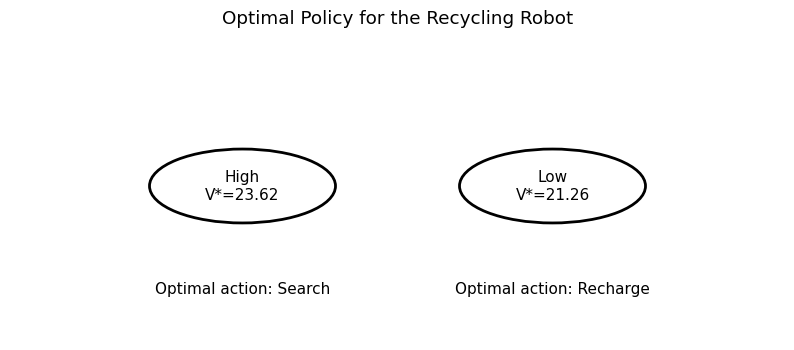

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

high = (0.3, 0.5)
low = (0.7, 0.5)

for point, label, value in [
    (high, "High", V_high),
    (low, "Low", V_low)
]:
    ax.add_patch(Circle(point, 0.12, fill=False, linewidth=2))
    ax.text(
        point[0], point[1],
        f"{label}\nV*={value:.2f}",
        ha="center", va="center"
    )

ax.text(
    0.3, 0.15,
    f"Optimal action: {optimal_policy['High']}",
    ha="center"
)

ax.text(
    0.7, 0.15,
    f"Optimal action: {optimal_policy['Low']}",
    ha="center"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.title("Optimal Policy for the Recycling Robot")
plt.show()


# 15. Experiment: How does gamma affect the solution?

The discount factor determines how strongly the agent values future rewards.

Try changing $\gamma$ and observe:

- the value of High,
- the value of Low,
- the optimal policy.


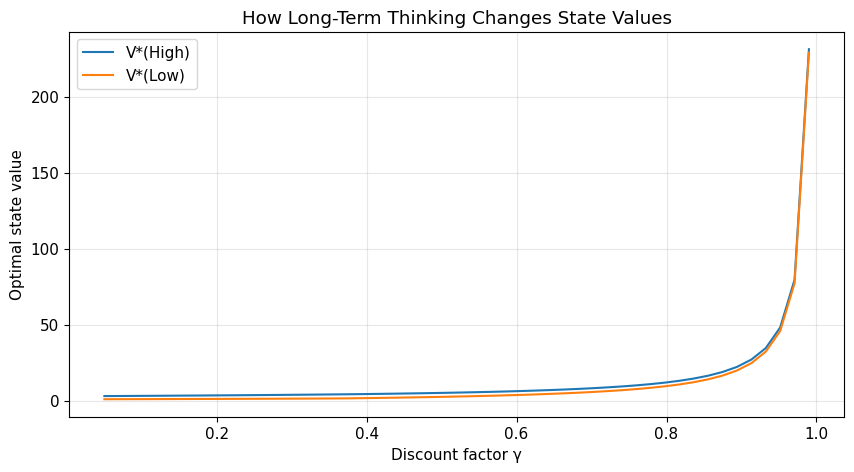

In [17]:
gamma_grid = np.linspace(0.05, 0.99, 50)

high_values = []
low_values = []

for g in gamma_grid:
    vh, vl, _, _, _ = value_iteration_robot(
        alpha=alpha,
        beta=beta,
        r_search=r_search,
        r_wait=r_wait,
        r_rescue=r_rescue,
        gamma=g
    )

    high_values.append(vh)
    low_values.append(vl)

plt.plot(gamma_grid, high_values, label="V*(High)")
plt.plot(gamma_grid, low_values, label="V*(Low)")
plt.xlabel("Discount factor γ")
plt.ylabel("Optimal state value")
plt.title("How Long-Term Thinking Changes State Values")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 16. Main takeaways

## Value function

A value function represents expected cumulative future reward.

$$
V_\pi(s)
=
\mathbb{E}_\pi[G_t|S_t=s]
$$

## Action-value function

The action-value function includes both the current state and a selected action.

$$
Q_\pi(s,a)
=
\mathbb{E}_\pi[
G_t|S_t=s,A_t=a
]
$$

## Bellman equation

The current value can be expressed through:

$$
\text{immediate reward}
+
\text{discounted value of the future}
$$

## Optimality

An optimal policy chooses actions with maximum long-term expected return.

$$
V_*(s)=\max_a Q_*(s,a)
$$

## Bellman optimality equation

$$
V_*(s)
=
\max_a
\sum_{s',r}
p(s',r|s,a)
[
r+\gamma V_*(s')
]
$$

## Value iteration

Repeated Bellman optimality updates can converge to the optimal value function and reveal the optimal policy.
